In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Heart_Disease_Prediction.csv")

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [5]:
df.shape

(270, 14)

In [6]:
df.describe

<bound method NDFrame.describe of      Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0     70    1                4  130          322             0            2   
1     67    0                3  115          564             0            2   
2     57    1                2  124          261             0            0   
3     64    1                4  128          263             0            0   
4     74    0                2  120          269             0            2   
..   ...  ...              ...  ...          ...           ...          ...   
265   52    1                3  172          199             1            0   
266   44    1                2  120          263             0            0   
267   56    0                2  140          294             0            2   
268   57    1                4  140          192             0            0   
269   67    1                4  160          286             0            2   

     Max HR  Exer

In [7]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [9]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [10]:
df.fillna("Age", inplace=True)

In [11]:
#df.drop(columns=["parent_education", "study_method", "gender","school_type"], inplace=True)  #Removing object columns
#df["Age"].fillna(df["Age"].median(), inplace=True)
#df["Sex"].fillna(df["Sex"].mode()[0], inplace=True)


In [12]:
numeric_cols=df.select_dtypes(include=["int64","float64"]).columns

In [13]:
numeric_cols

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

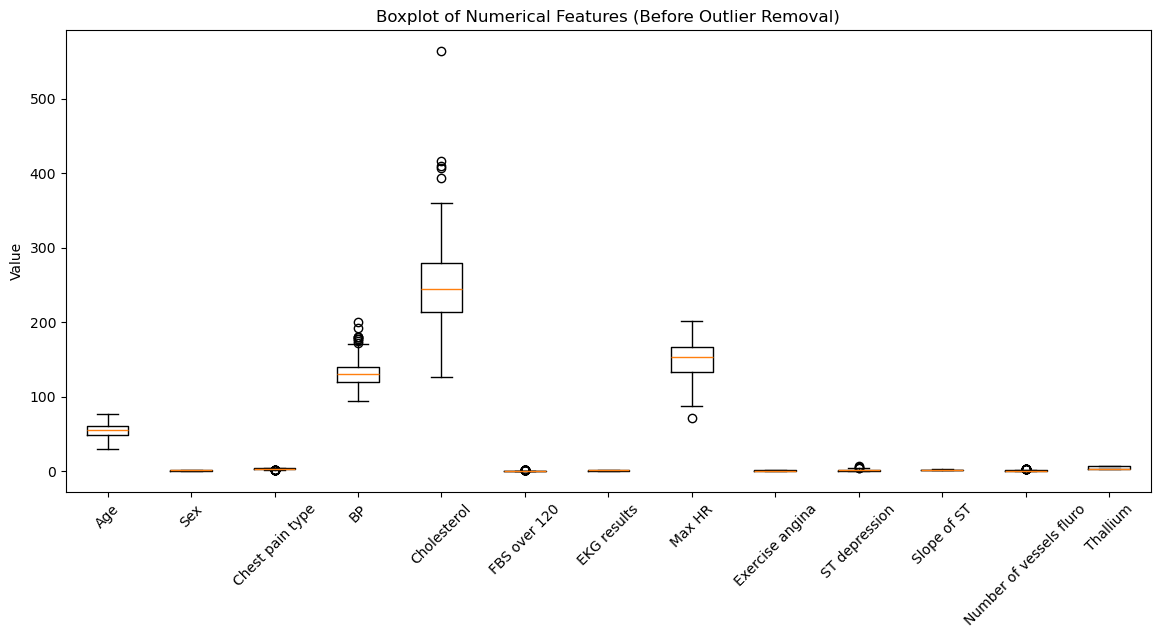

In [14]:
plt.figure(figsize=(14,6))
plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols)
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features (Before Outlier Removal)")
plt.ylabel("Value")
plt.show()

In [15]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers= df[(df["Age"] < lower) | (df["Age"] > upper)]
print("Age outlier:", outliers.shape[0])

Age outlier: 0


<function matplotlib.pyplot.show(close=None, block=None)>

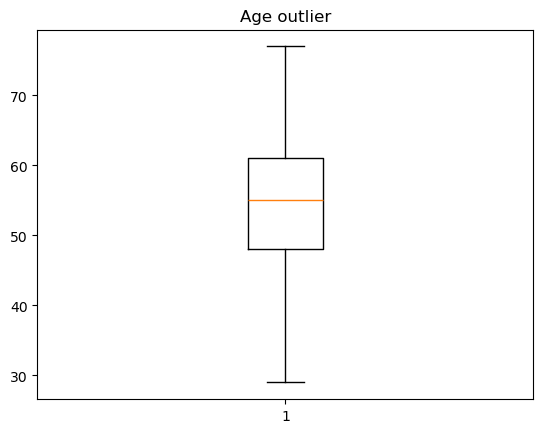

In [16]:
plt.boxplot(df["Age"])
plt.title("Age outlier")
plt.show

In [17]:
Q1 = df["BP"].quantile(0.25)
Q3 = df["BP"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

bp_outliers = df[(df["BP"] < lower) | (df["BP"] > upper)]
print("BP outliers:", bp_outliers.shape[0])

BP outliers: 9


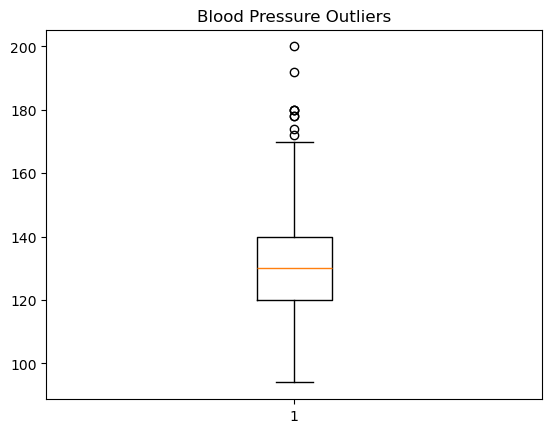

In [18]:
plt.boxplot(df["BP"])
plt.title("Blood Pressure Outliers")
plt.show()

In [19]:
df=df[
    (df["BP"]>=lower) &
    (df["BP"]<=upper)
]

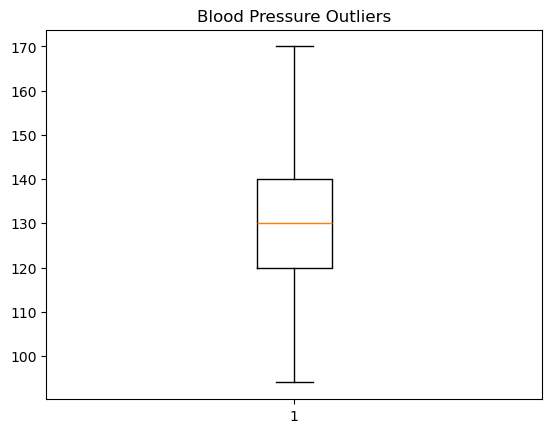

In [20]:
plt.boxplot(df["BP"])
plt.title("Blood Pressure Outliers")
plt.show()

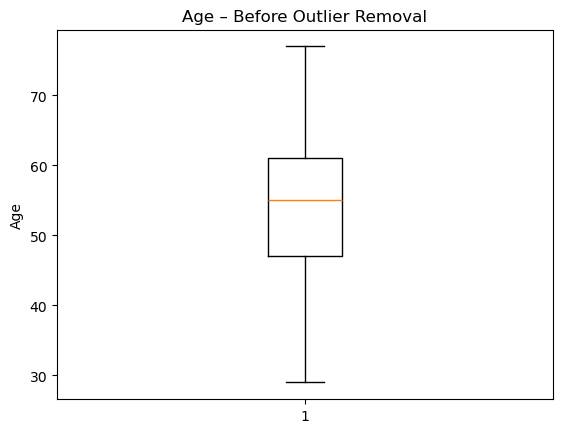

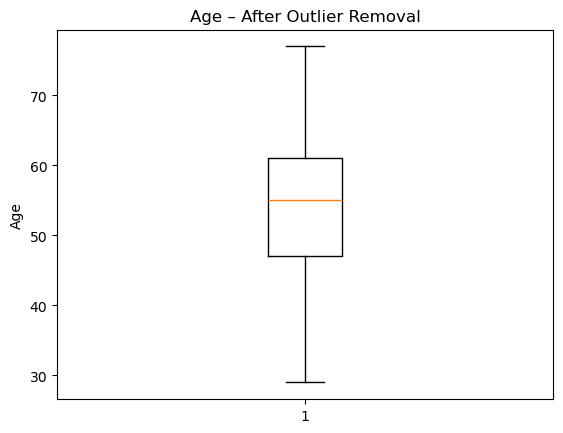

Age: remaining rows → 261


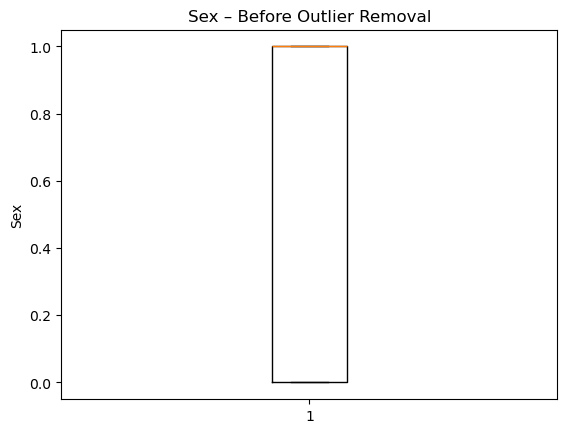

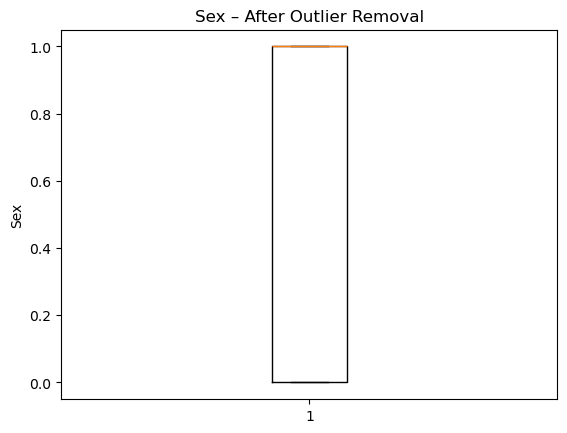

Sex: remaining rows → 261


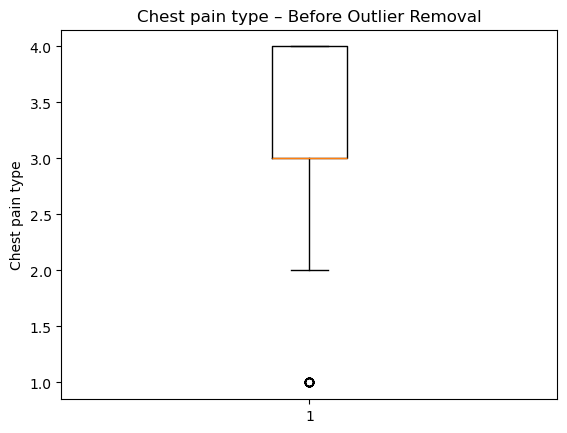

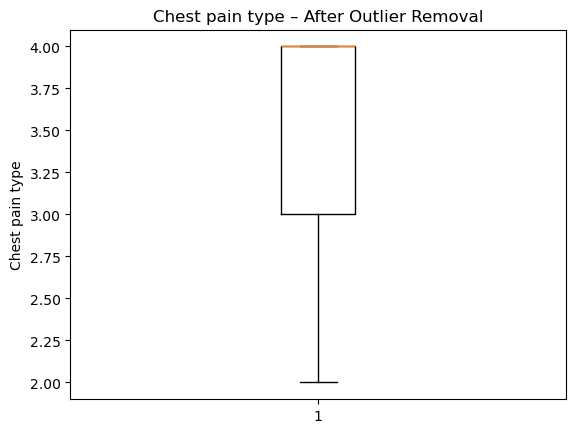

Chest pain type: remaining rows → 242


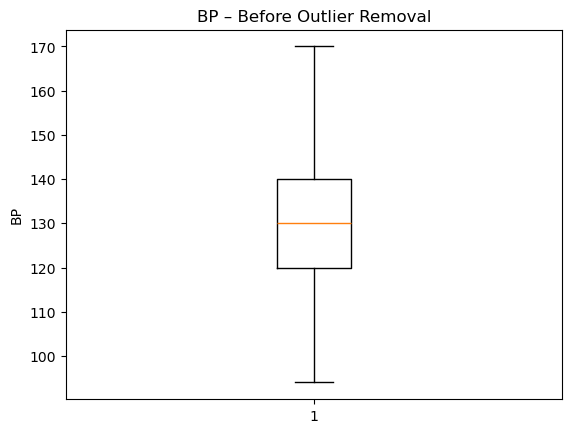

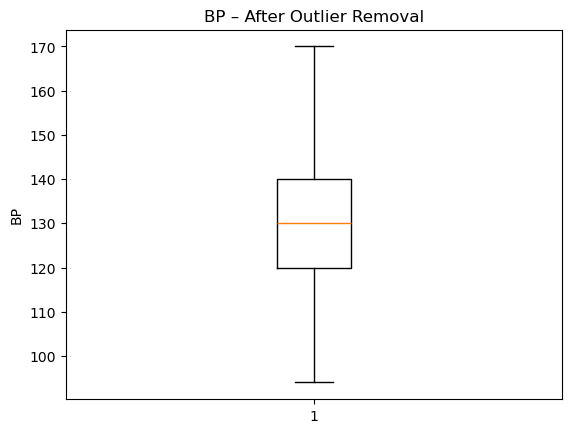

BP: remaining rows → 242


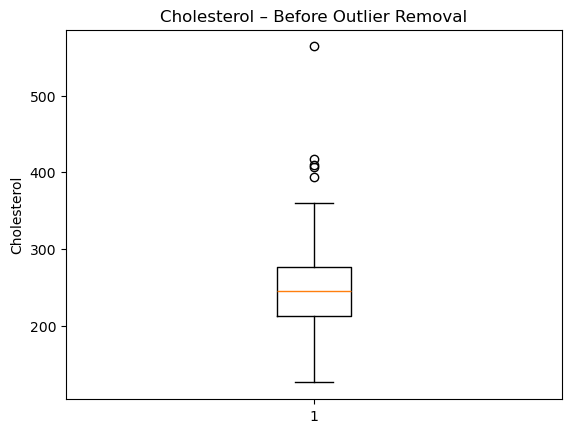

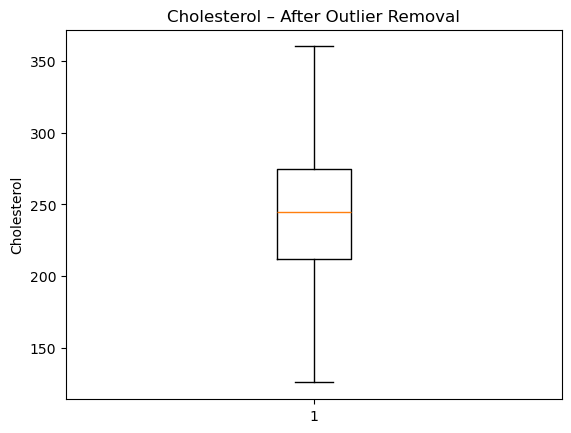

Cholesterol: remaining rows → 237


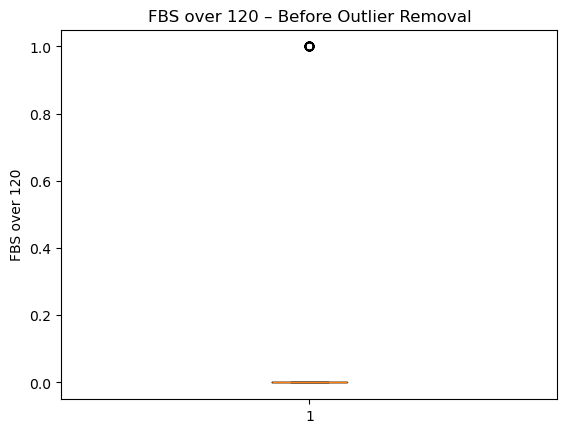

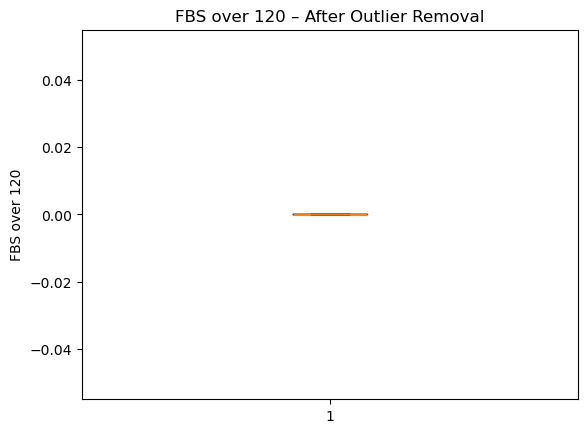

FBS over 120: remaining rows → 207


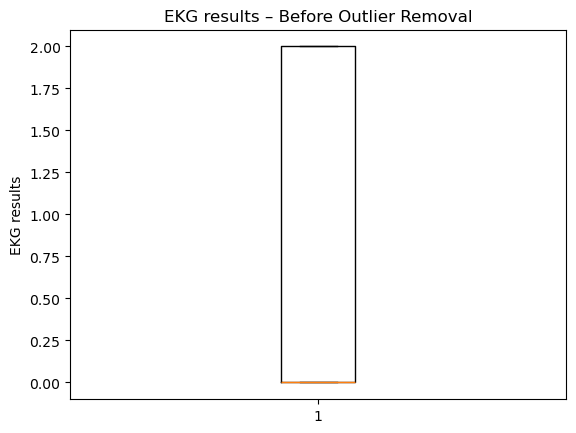

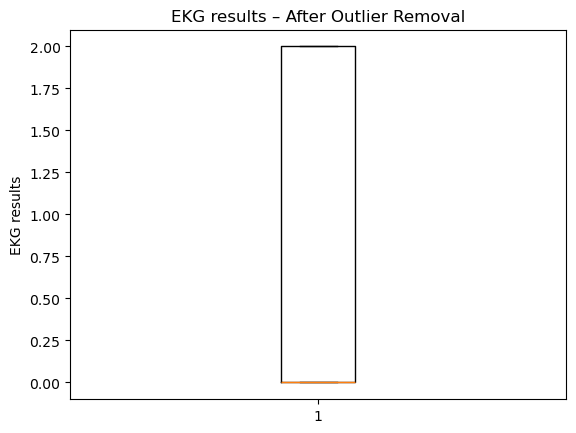

EKG results: remaining rows → 207


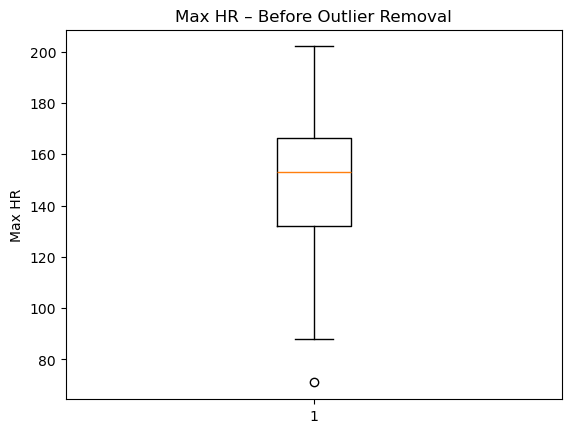

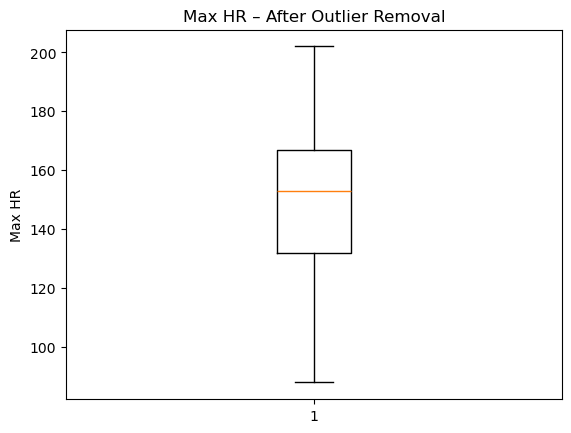

Max HR: remaining rows → 206


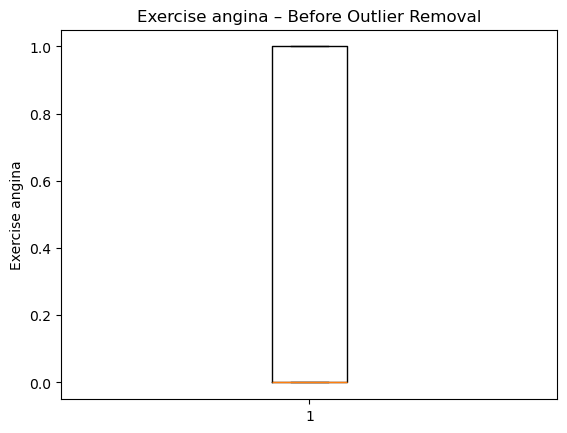

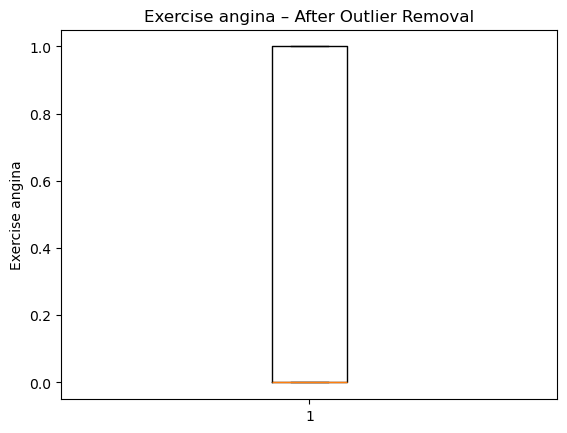

Exercise angina: remaining rows → 206


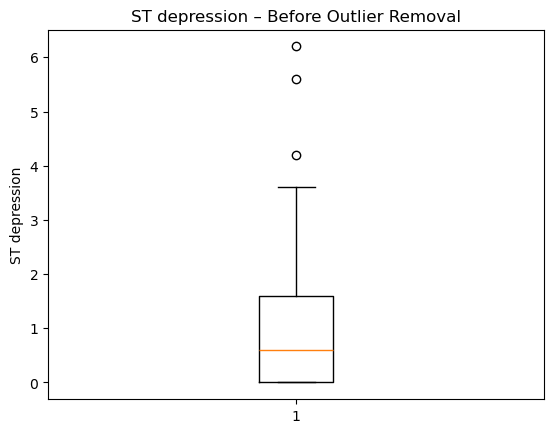

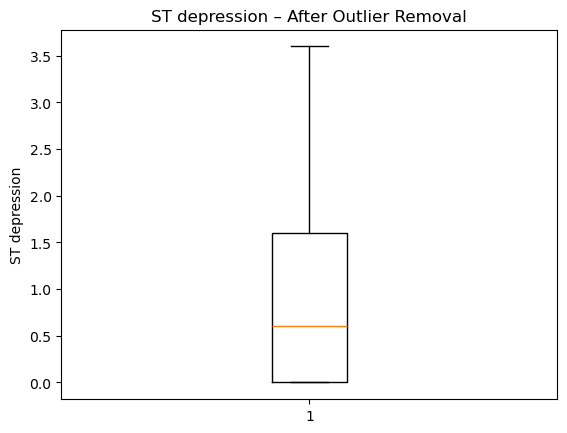

ST depression: remaining rows → 203


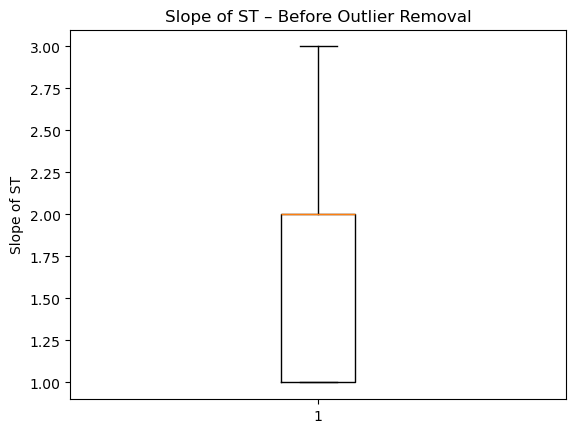

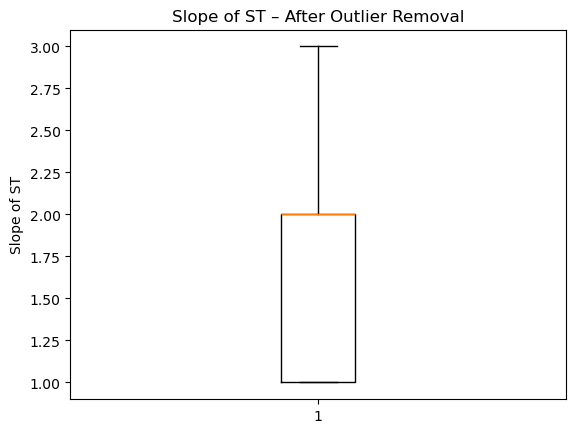

Slope of ST: remaining rows → 203


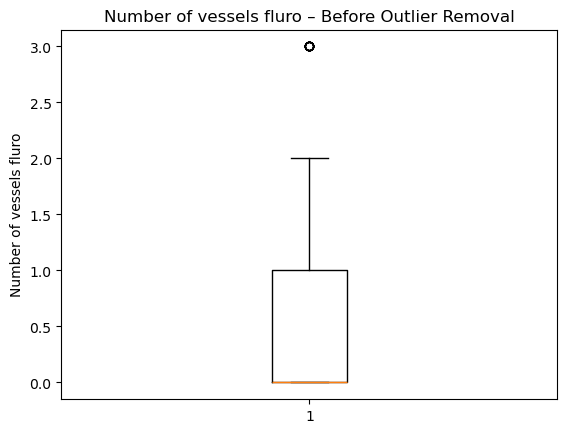

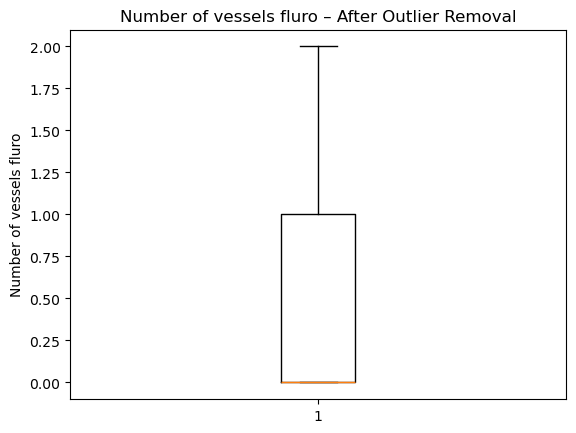

Number of vessels fluro: remaining rows → 192


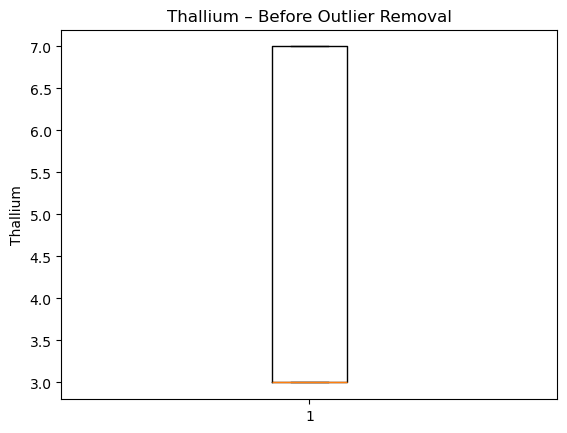

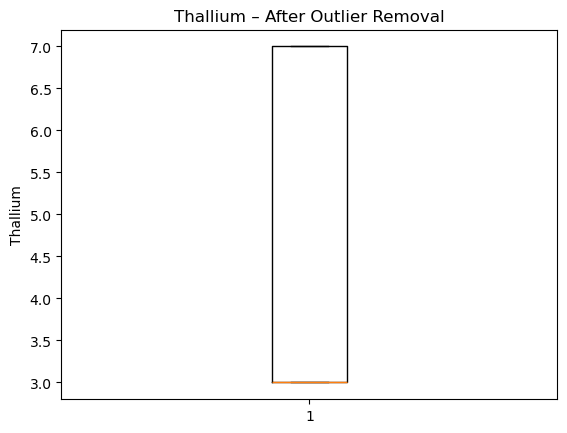

Thallium: remaining rows → 192


In [21]:
for col in numeric_cols:
    
    plt.boxplot(df[col])
    plt.title(f"{col} – Before Outlier Removal")
    plt.ylabel(col)
    plt.show()
    
    # IQR CALCULATION
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # REMOVE OUTLIERS
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    # AFTER PLOT
    plt.boxplot(df[col])
    plt.title(f"{col} – After Outlier Removal")
    plt.ylabel(col)
    plt.show()
    
    print(f"{col}: remaining rows → {df.shape[0]}")

In [22]:
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

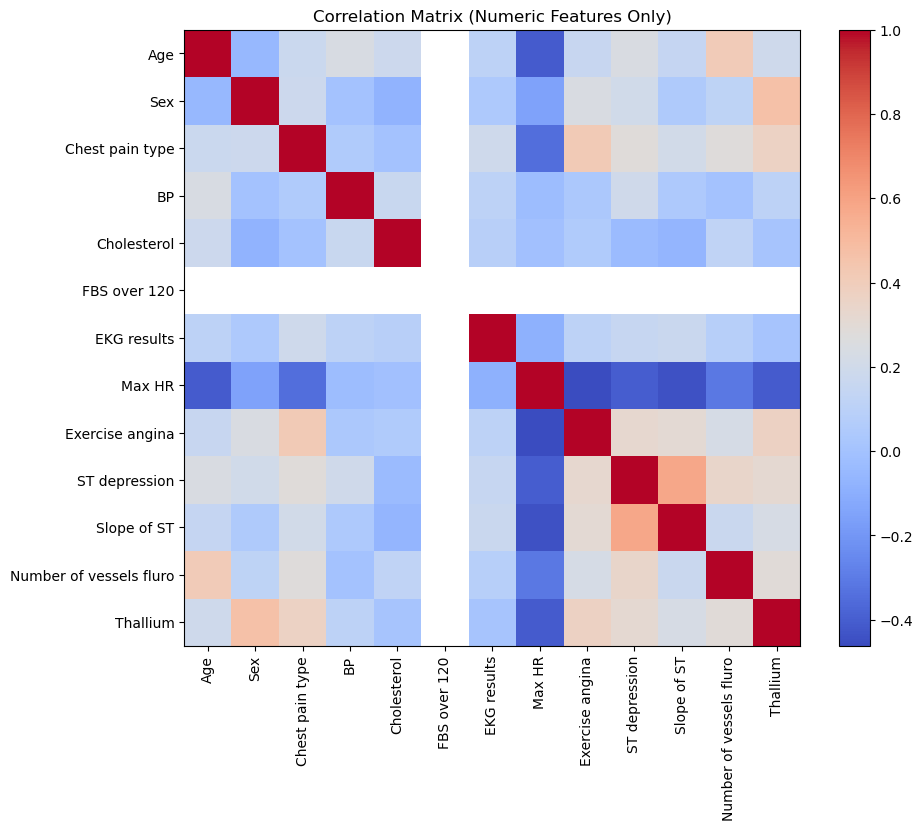

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

In [24]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
) #avoids double counting

In [25]:
threshold = 0.65

to_ignore = []

for col in upper_triangle.columns:
    if any(upper_triangle[col].abs() >= threshold):
        to_ignore.append(col)

print("Features to ignore (highly correlated):")
print(to_ignore)


Features to ignore (highly correlated):
[]


In [26]:
df["Heart Disease"]=df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

In [27]:
target_corr = df.corr()["Heart Disease"].abs().sort_values(ascending=False)
print(target_corr)

Heart Disease              1.000000
Thallium                   0.598782
Number of vessels fluro    0.474720
ST depression              0.472007
Chest pain type            0.467068
Max HR                     0.429397
Exercise angina            0.421668
Sex                        0.395919
Slope of ST                0.346492
Age                        0.219552
EKG results                0.188217
BP                         0.099870
Cholesterol                0.089817
FBS over 120                    NaN
Name: Heart Disease, dtype: float64


In [28]:
target = "Heart Disease"

target_corr = df.corr()[target].abs()

low_threshold = 0.09

low_dependency_features = target_corr[
    (target_corr < low_threshold) & (target_corr.index != target)
].index.tolist()

print("Low dependency features:")
print(low_dependency_features)


Low dependency features:
['Cholesterol']


In [29]:
df = df.drop(columns=["FBS over 120"])
df = df.drop(columns=low_dependency_features)

In [30]:
df.describe()

,Age,Sex,Chest pain type,BP,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,53.177083,0.666667,3.338542,127.781250,0.953125,150.552083,0.317708,0.927604,1.526042,0.473958,4.578125,0.416667
std,9.158288,0.472637,0.769153,15.219307,0.998895,22.821350,0.466803,1.011876,0.578271,0.693537,1.923713,0.494296
min,29.000000,0.000000,2.000000,94.000000,0.000000,88.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,45.000000,0.000000,3.000000,119.500000,0.000000,136.750000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,128.000000,0.000000,155.500000,0.000000,0.600000,1.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,2.000000,168.000000,1.000000,1.525000,2.000000,1.000000,7.000000,1.000000
max,76.000000,1.000000,4.000000,170.000000,2.000000,202.000000,1.000000,3.600000,3.000000,2.000000,7.000000,1.000000


In [31]:
df.head()

,Age,Sex,Chest pain type,BP,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
2,57,1,2,124,0,141,0,0.3,1,0,7,1
3,64,1,4,128,0,105,1,0.2,2,1,7,0
4,74,0,2,120,2,121,1,0.2,1,1,3,0
5,65,1,4,120,0,140,0,0.4,1,0,7,0
7,59,1,4,110,2,142,1,1.2,2,1,7,1


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 2 to 268
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      192 non-null    int64  
 1   Sex                      192 non-null    int64  
 2   Chest pain type          192 non-null    int64  
 3   BP                       192 non-null    int64  
 4   EKG results              192 non-null    int64  
 5   Max HR                   192 non-null    int64  
 6   Exercise angina          192 non-null    int64  
 7   ST depression            192 non-null    float64
 8   Slope of ST              192 non-null    int64  
 9   Number of vessels fluro  192 non-null    int64  
 10  Thallium                 192 non-null    int64  
 11  Heart Disease            192 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 19.5 KB


In [33]:
#df = pd.get_dummies(df, drop_first=True) for encodind data

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

x_scaled = scaler.fit_transform(x)

In [71]:
df["Heart Disease"].value_counts(normalize=True)

Heart Disease
0    0.583333
1    0.416667
Name: proportion, dtype: float64

In [73]:
from sklearn.model_selection import train_test_split
x=df.drop("Heart Disease",axis=1)
y=df["Heart Disease"]

In [77]:
x_train,x_temp,y_train,y_temp = train_test_split(
    x,y,
    test_size=0.30,
    random_state=42,
    stratify=y
) #First split -> Train (70%) + Temp(30%)

In [81]:
x_val,x_test,y_val,y_test = train_test_split(
    x_temp,y_temp,
    test_size=0.50,
    random_state = 42,
    stratify=y_temp
)

In [85]:
print("Train size:", x_train.shape)
print("Validation size:", x_val.shape)
print("Test size:", x_test.shape)

Train size: (134, 11)
Validation size: (29, 11)
Test size: (29, 11)


In [87]:
#FEATURE SCALING (IMPORTANT FOR MANY MODELS)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(x_train)
X_val_s   = scaler.transform(x_val)
X_test_s  = scaler.transform(x_test)


In [89]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_train_s, y_train)

val_pred = lr.predict(X_val_s)
test_pred = lr.predict(X_test_s)

print("Logistic Regression")
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))


Logistic Regression
Validation Accuracy: 0.7931034482758621
Test Accuracy: 0.7586206896551724


In [123]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_train_s, y_train)

val_pred = lr.predict(X_val_s)
test_pred = lr.predict(X_test_s)

print("Linear Regression")
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Linear Regression
Validation Accuracy: 0.7931034482758621
Test Accuracy: 0.7586206896551724


In [107]:
#K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

print("\nKNN")
print("Validation Accuracy:", accuracy_score(y_val, knn.predict(X_val_s)))
print("Test Accuracy:", accuracy_score(y_test, knn.predict(X_test_s)))


KNN
Validation Accuracy: 0.8620689655172413
Test Accuracy: 0.8620689655172413


In [109]:
#SVM
from sklearn.svm import SVC

svm = SVC(class_weight="balanced")
svm.fit(X_train_s, y_train)

print("\nSVM")
print("Validation Accuracy:", accuracy_score(y_val, svm.predict(X_val_s)))
print("Test Accuracy:", accuracy_score(y_test, svm.predict(X_test_s)))


SVM
Validation Accuracy: 0.8275862068965517
Test Accuracy: 0.8275862068965517


In [115]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(x_train, y_train)

print("\nRandom Forest")
print("Validation Accuracy:", accuracy_score(y_val, rf.predict(x_val)))
print("Test Accuracy:", accuracy_score(y_test, rf.predict(x_test)))


Random Forest
Validation Accuracy: 0.8275862068965517
Test Accuracy: 0.8620689655172413
